В данном датасете обучаем логистическую регрессию для дальнейшего предсказния машин, которые сойдут с дистанции

In [ ]:
!pip uninstall scikit-learn -y
!pip install scikit-learn==1.8.0

Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 20.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
import warnings
import joblib
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("f1_data_pca.csv")

In [ ]:
df = df.sort_values(['Year', 'Round']).reset_index(drop=True)
df['DNF'] = 1 - df['Is_finished']

Признаки, оценивающие как часто водитель сходил с дистанции

In [ ]:
def calculate_driver_ratings(historical_data, current_year, current_round, drivers_encoded_list):
    past_data = historical_data[
        ((historical_data['Year'] < current_year) |
         ((historical_data['Year'] == current_year) &
          (historical_data['Round'] < current_round)))
    ].copy()

    if len(past_data) == 0:
        return pd.DataFrame()

    ratings = []

    for driver_enc in drivers_encoded_list:
        driver_data = past_data[past_data['Driver_encoded'] == driver_enc]

        if len(driver_data) > 0:
            finish_rate = driver_data['Is_finished'].mean()
            dnf_rate = 1 - finish_rate
            mechanical_rate = driver_data['Is_mechanical'].mean() if 'Is_mechanical' in driver_data.columns else 0
            accident_rate = driver_data['Is_accident'].mean() if 'Is_accident' in driver_data.columns else 0

            last_5 = driver_data.sort_values(['Year', 'Round'], ascending=False).head(5)
            finish_rate_last_5 = last_5['Is_finished'].mean() if len(last_5) > 0 else finish_rate

            street_data = driver_data[driver_data['Streets_or_not'] == 1]
            if len(street_data) > 0:
                street_dnf_rate = 1 - street_data['Is_finished'].mean()
                street_races = len(street_data)
            else:
                street_dnf_rate = dnf_rate
                street_races = 0
        else:
            finish_rate = past_data['Is_finished'].mean()
            dnf_rate = 1 - finish_rate
            mechanical_rate = past_data['Is_mechanical'].mean() if 'Is_mechanical' in past_data.columns else 0.05
            accident_rate = past_data['Is_accident'].mean() if 'Is_accident' in past_data.columns else 0.05
            finish_rate_last_5 = finish_rate
            street_dnf_rate = dnf_rate
            street_races = 0

        ratings.append({
            'Driver_encoded': driver_enc,
            'finish_rate': float(finish_rate),
            'dnf_rate': float(dnf_rate),
            'mechanical_rate': float(mechanical_rate),
            'accident_rate': float(accident_rate),
            'finish_rate_last_5': float(finish_rate_last_5),
            'street_dnf_rate': float(street_dnf_rate),
            'street_races': street_races
        })

    return pd.DataFrame(ratings)

Модель с множеством признаков

In [ ]:
feature_columns = [
    'result_gap_normalized', 'result_vs_team_avg', 'q_x_team', 'avg_pit_x_q',
    'super_ratio_1', 'Average_pit_stop', 'finish_rate_last_5', 'adaptation_score',
    'meta_ratio', 'dnf_rate', 'finish_rate', 'Q', 'rank_x_team',
    'temp_humidity_ratio', 'best_last_3', 'form_x_difficulty', 'Salary_encoded',
    'mechanical_rate', 'pitstop_to_speed_ratio', 'brake_x_turns', 'brake_x_wind',
    'Points_before_race', 'consistency_vs_avg', 'Start_Position',
    'tracktemp_x_salary', 'points_to_leader', 'tracktemp_x_points_log',
    'temp_gap_x_team', 'form_volatility', 'tracktemp_x_start', 'Engine_Ferrari',
    'avg_last_5', 'accident_rate', 'brake_x_speed_track', 'avg_points_ratio',
    'Quantity_of_turns', 'factory_x_reg',
]

In [ ]:
rating_features = ['finish_rate', 'dnf_rate', 'mechanical_rate', 'accident_rate', 'finish_rate_last_5', 'street_dnf_rate', 'street_races']
all_features = feature_columns

In [ ]:
X_list = []
y_list = []

for (year, round_num), race_data in df.groupby(['Year', 'Round']):
    if round_num == 1:
        past_data = df[df['Year'] < year]
    else:
        past_data = df[
            ((df['Year'] < year) |
             ((df['Year'] == year) & (df['Round'] < round_num)))
        ]


    drivers_enc = race_data['Driver_encoded'].unique().tolist()
    ratings = calculate_driver_ratings(past_data, year, round_num, drivers_enc)

    race_base = race_data[[c for c in feature_columns if c not in rating_features] + ['Driver_encoded', 'DNF']].copy()

    if len(ratings) > 0:
        race_with_ratings = race_base.merge(ratings, on='Driver_encoded', how='left')
        for feat in rating_features:
            if feat not in race_with_ratings.columns:
                race_with_ratings[feat] = 0.5
    else:
        race_with_ratings = race_base.copy()
        for feat in rating_features:
            race_with_ratings[feat] = 0.5

    existing_features = [f for f in all_features if f in race_with_ratings.columns]
    X_list.append(race_with_ratings[existing_features])
    y_list.append(race_with_ratings['DNF'])

X = pd.concat(X_list, ignore_index=True)
y = pd.concat(y_list, ignore_index=True)

pipe = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    LogisticRegression(
        penalty='l2',
        C=1.0,
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    )
)

tscv = TimeSeriesSplit(n_splits=5)

accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
roc_auc_scores = []
coef_list = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_val)
    y_pred_proba = pipe.predict_proba(X_val)[:, 1]

    log_reg = pipe.named_steps['logisticregression']
    coef_list.append(log_reg.coef_[0])

    accuracy_scores.append(accuracy_score(y_val, y_pred))
    precision_scores.append(precision_score(y_val, y_pred))
    recall_scores.append(recall_score(y_val, y_pred))
    f1_scores.append(f1_score(y_val, y_pred))
    roc_auc_scores.append(roc_auc_score(y_val, y_pred_proba))

    print(f"Fold {fold}: Acc={accuracy_scores[-1]:.3f}, Prec={precision_scores[-1]:.3f}, Rec={recall_scores[-1]:.3f}, F1={f1_scores[-1]:.3f}")

print(f"Mean: Acc={np.mean(accuracy_scores):.3f}, Prec={np.mean(precision_scores):.3f}, Rec={np.mean(recall_scores):.3f}, F1={np.mean(f1_scores):.3f}, AUC={np.mean(roc_auc_scores):.3f}")

if len(coef_list) > 0:
    avg_coef = np.mean(coef_list, axis=0)
    if len(avg_coef) == len(X.columns):
        importance_df = pd.DataFrame({
            'feature': X.columns,
            'coef': avg_coef,
            'abs_coef': np.abs(avg_coef)
        }).sort_values('abs_coef', ascending=False)

        print("\nTop-15 features:")
        print(importance_df.head(15).to_string(index=False))

Fold 1: Acc=0.670, Prec=0.231, Rec=0.438, F1=0.302
Fold 2: Acc=0.709, Prec=0.192, Rec=0.372, F1=0.253
Fold 3: Acc=0.704, Prec=0.200, Rec=0.410, F1=0.269
Fold 4: Acc=0.675, Prec=0.157, Rec=0.370, F1=0.220
Fold 5: Acc=0.675, Prec=0.218, Rec=0.571, F1=0.315
Mean: Acc=0.687, Prec=0.200, Rec=0.432, F1=0.272, AUC=0.630

Top-15 features:
              feature      coef  abs_coef
        super_ratio_1  0.763050  0.763050
             q_x_team -0.596065  0.596065
result_gap_normalized  0.471328  0.471328
   result_vs_team_avg  0.471328  0.471328
          avg_pit_x_q  0.389626  0.389626
     adaptation_score -0.295703  0.295703
           avg_last_5  0.288096  0.288096
     Average_pit_stop -0.276828  0.276828
           meta_ratio  0.222907  0.222907
                    Q  0.217018  0.217018
        accident_rate  0.186373  0.186373
          rank_x_team -0.177750  0.177750
          finish_rate  0.149074  0.149074
             dnf_rate -0.149074  0.149074
   consistency_vs_avg  0.141786  0.14

In [ ]:
all_features = ["result_gap_normalized", "result_vs_team_avg","q_x_team","avg_pit_x_q","super_ratio_1",
                   "Average_pit_stop", "finish_rate_last_5","adaptation_score","dnf_rate","finish_rate",
                   "meta_ratio", "Q", "temp_humidity_ratio", "rank_x_team", "best_last_3"]

In [ ]:
feature_columns = ["result_gap_normalized", "result_vs_team_avg","q_x_team","avg_pit_x_q","super_ratio_1",
                   "Average_pit_stop", "finish_rate_last_5","adaptation_score","dnf_rate","finish_rate",
                   "meta_ratio", "Q", "temp_humidity_ratio", "rank_x_team", "best_last_3"]

In [ ]:
X_list = []
y_list = []

for (year, round_num), race_data in df.groupby(['Year', 'Round']):
    if round_num == 1:
        past_data = df[df['Year'] < year]
    else:
        past_data = df[
            ((df['Year'] < year) |
             ((df['Year'] == year) & (df['Round'] < round_num)))
        ]


    drivers_enc = race_data['Driver_encoded'].unique().tolist()
    ratings = calculate_driver_ratings(past_data, year, round_num, drivers_enc)

    race_base = race_data[[c for c in feature_columns if c not in rating_features] + ['Driver_encoded', 'DNF']].copy()

    if len(ratings) > 0:
        race_with_ratings = race_base.merge(ratings, on='Driver_encoded', how='left')
        for feat in rating_features:
            if feat not in race_with_ratings.columns:
                race_with_ratings[feat] = 0.5
    else:
        race_with_ratings = race_base.copy()
        for feat in rating_features:
            race_with_ratings[feat] = 0.5

    existing_features = [f for f in all_features if f in race_with_ratings.columns]
    X_list.append(race_with_ratings[existing_features])
    y_list.append(race_with_ratings['DNF'])

X = pd.concat(X_list, ignore_index=True)
y = pd.concat(y_list, ignore_index=True)

pipe = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    LogisticRegression(
        penalty='l2',
        C=1.0,
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    )
)

tscv = TimeSeriesSplit(n_splits=5)

accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
roc_auc_scores = []
coef_list = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_val)
    y_pred_proba = pipe.predict_proba(X_val)[:, 1]

    log_reg = pipe.named_steps['logisticregression']
    coef_list.append(log_reg.coef_[0])

    accuracy_scores.append(accuracy_score(y_val, y_pred))
    precision_scores.append(precision_score(y_val, y_pred))
    recall_scores.append(recall_score(y_val, y_pred))
    f1_scores.append(f1_score(y_val, y_pred))
    roc_auc_scores.append(roc_auc_score(y_val, y_pred_proba))

    print(f"Fold {fold}: Acc={accuracy_scores[-1]:.3f}, Prec={precision_scores[-1]:.3f}, Rec={recall_scores[-1]:.3f}, F1={f1_scores[-1]:.3f}")

print(f"Mean: Acc={np.mean(accuracy_scores):.3f}, Prec={np.mean(precision_scores):.3f}, Rec={np.mean(recall_scores):.3f}, F1={np.mean(f1_scores):.3f}, AUC={np.mean(roc_auc_scores):.3f}")

if len(coef_list) > 0:
    avg_coef = np.mean(coef_list, axis=0)
    if len(avg_coef) == len(X.columns):
        importance_df = pd.DataFrame({
            'feature': X.columns,
            'coef': avg_coef,
            'abs_coef': np.abs(avg_coef)
        }).sort_values('abs_coef', ascending=False)


Fold 1: Acc=0.713, Prec=0.248, Rec=0.375, F1=0.299
Fold 2: Acc=0.748, Prec=0.203, Rec=0.308, F1=0.245
Fold 3: Acc=0.687, Prec=0.195, Rec=0.436, F1=0.270
Fold 4: Acc=0.694, Prec=0.159, Rec=0.342, F1=0.217
Fold 5: Acc=0.677, Prec=0.219, Rec=0.571, F1=0.317
Mean: Acc=0.704, Prec=0.205, Rec=0.406, F1=0.269, AUC=0.638


In [ ]:
threshold = 0.5

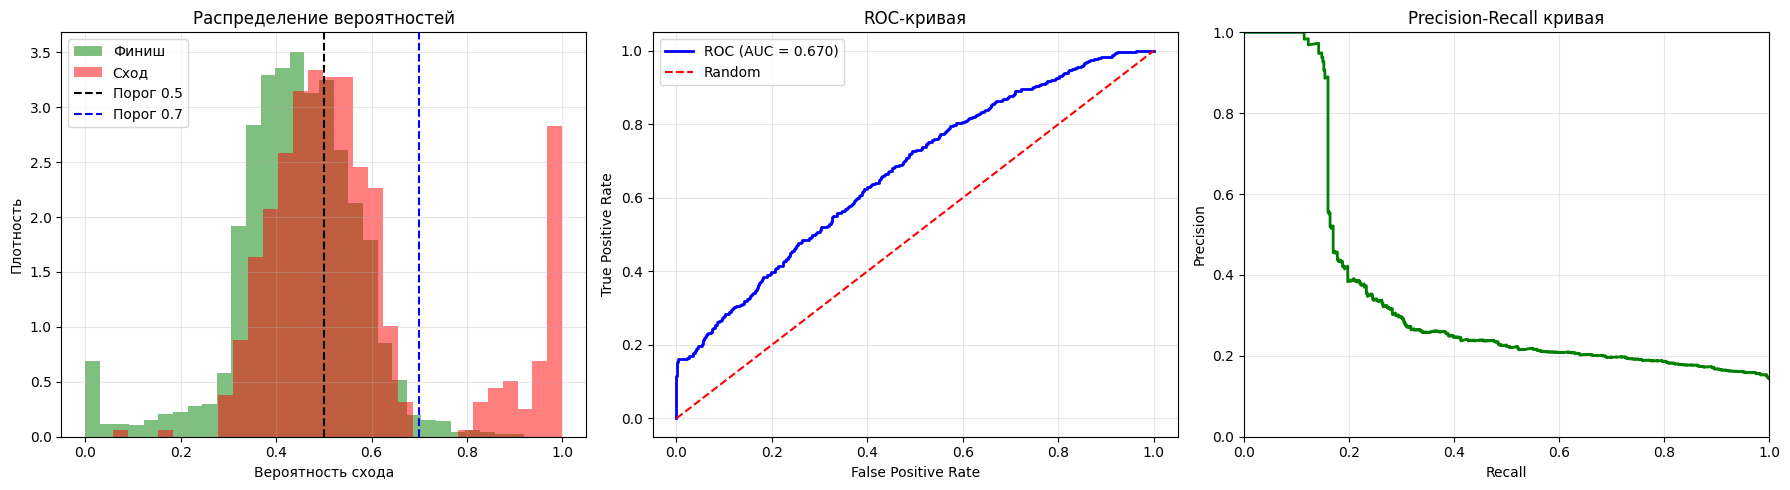

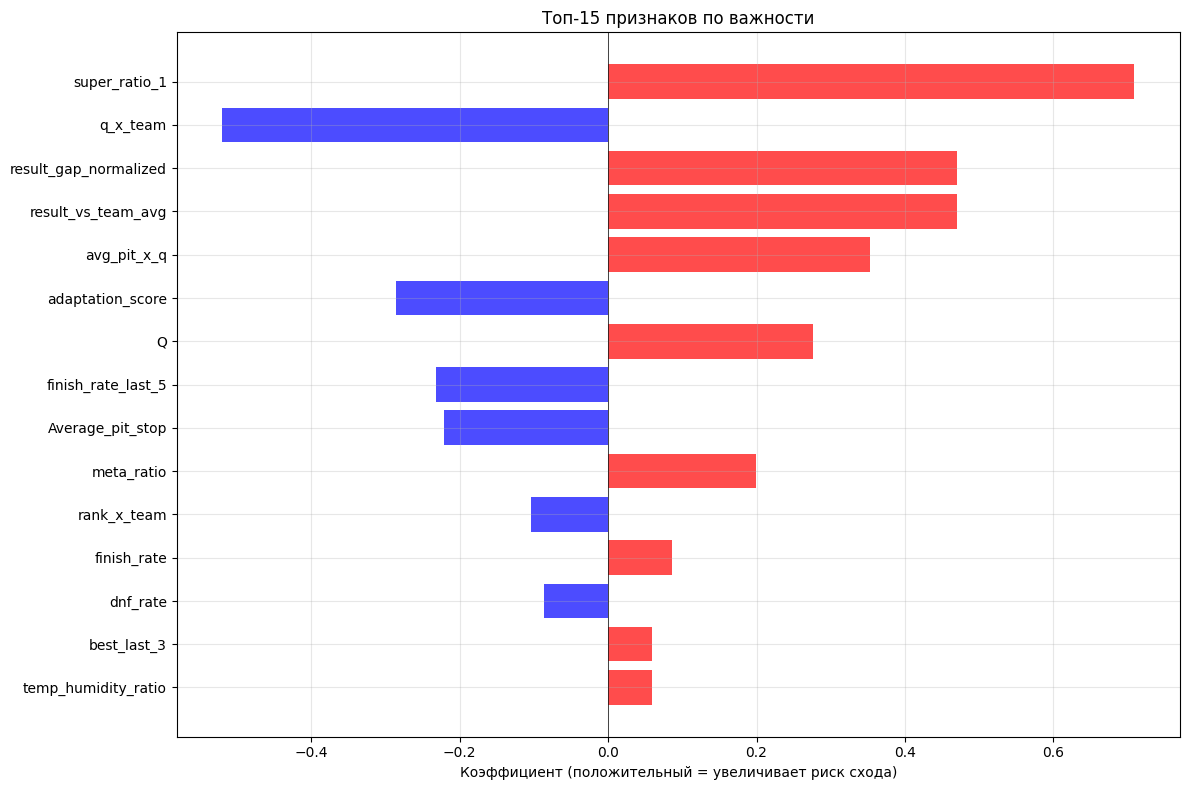

In [ ]:
if len(coef_list) > 0:
    y_pred_proba_all = pipe.predict_proba(X)[:, 1]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].hist(y_pred_proba_all[y == 0], bins=30, alpha=0.5, label='Финиш', color='green', density=True)
    axes[0].hist(y_pred_proba_all[y == 1], bins=30, alpha=0.5, label='Сход', color='red', density=True)
    axes[0].axvline(x=0.5, color='black', linestyle='--', label='Порог 0.5')
    axes[0].axvline(x=0.7, color='blue', linestyle='--', label='Порог 0.7')
    axes[0].set_xlabel('Вероятность схода')
    axes[0].set_ylabel('Плотность')
    axes[0].set_title('Распределение вероятностей')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    from sklearn.metrics import roc_curve, auc
    fpr, tpr, _ = roc_curve(y, y_pred_proba_all)
    roc_auc = auc(fpr, tpr)

    axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
    axes[1].plot([0, 1], [0, 1], 'r--', label='Random')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC-кривая')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    from sklearn.metrics import precision_recall_curve
    precision_curve, recall_curve, _ = precision_recall_curve(y, y_pred_proba_all)

    axes[2].plot(recall_curve, precision_curve, 'g-', linewidth=2)
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].set_title('Precision-Recall кривая')
    axes[2].grid(True, alpha=0.3)
    axes[2].set_xlim([0, 1])
    axes[2].set_ylim([0, 1])

    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(12, 8))
    colors = ['red' if c > 0 else 'blue' for c in importance_df.head(15)['coef']]
    plt.barh(importance_df.head(15)['feature'], importance_df.head(15)['coef'], color=colors, alpha=0.7)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.xlabel('Коэффициент (положительный = увеличивает риск схода)')
    plt.title('Топ-15 признаков по важности')
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Дообучение на 2025


Размер X_train: (3053, 15)
Размер X_fine: (479, 15)

бучение базовой модели на 2018-2024

Базовая модель (2018-2024):
   Accuracy: 0.8622
   Precision: 0.3889
   Recall: 0.2414
   F1-score: 0.2979
   Матрица ошибок: TN=399, FP=22, FN=44, TP=14

Дообучение на данных 2025 года

Дообученная модель (2018-2025):
   Accuracy: 0.8643
   Precision: 0.4000
   Recall: 0.2414
   F1-score: 0.3011
   Матрица ошибок: TN=400, FP=21, FN=44, TP=14

Улучшение:
   Accuracy: ++0.0021
   F1-score: ++0.0032
   TP: 14 → 14 (+0)
   FP: 22 → 21 (-1)


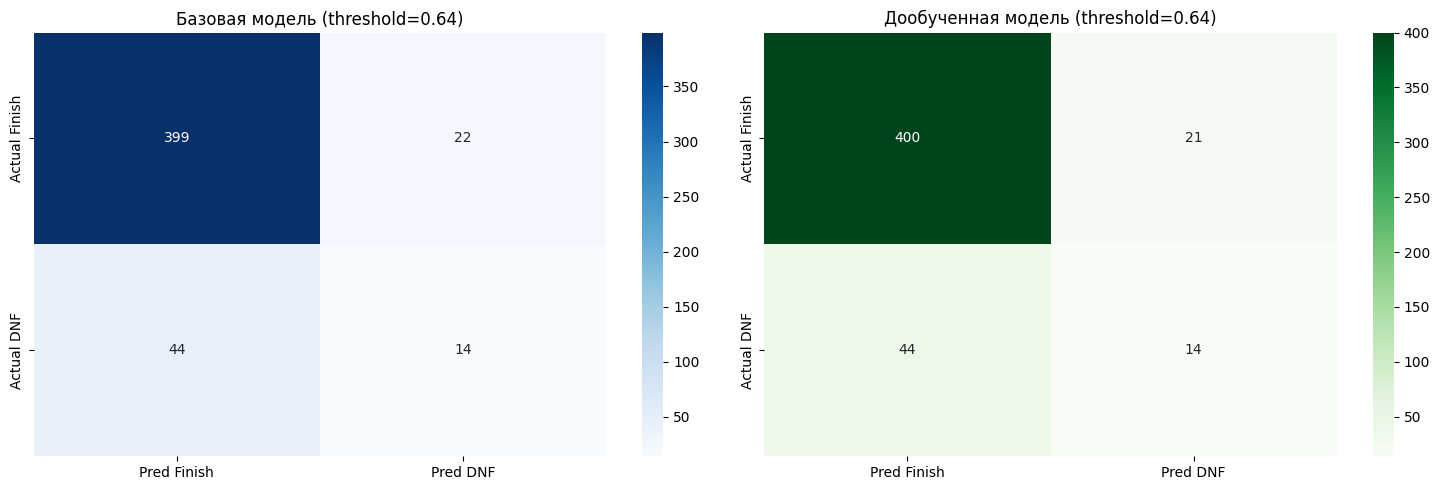

['dnf_model.pkl']

In [ ]:
    train_mask = df['Year'] < 2025
    fine_tune_mask = df['Year'] == 2025
    threshold = 0.64
    X_train = X[train_mask].copy()
    y_train = y[train_mask].copy()
    X_fine = X[fine_tune_mask].copy()
    y_fine = y[fine_tune_mask].copy()

    print(f"\nРазмер X_train: {X_train.shape}")
    print(f"Размер X_fine: {X_fine.shape}")
    print("\nбучение базовой модели на 2018-2024")
    base_pipeline = make_pipeline(
        SimpleImputer(strategy='median'),
        StandardScaler(),
        LogisticRegression(
            penalty='l2',
            C=1.0,
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        )
    )
    base_pipeline.fit(X_train, y_train)

    y_proba_base = base_pipeline.predict_proba(X_fine)[:, 1]
    y_pred_base = (y_proba_base >= threshold).astype(int)

    tn_base, fp_base, fn_base, tp_base = confusion_matrix(y_fine, y_pred_base).ravel()

    print(f"\nБазовая модель (2018-2024):")
    print(f"   Accuracy: {accuracy_score(y_fine, y_pred_base):.4f}")
    print(f"   Precision: {precision_score(y_fine, y_pred_base):.4f}")
    print(f"   Recall: {recall_score(y_fine, y_pred_base):.4f}")
    print(f"   F1-score: {f1_score(y_fine, y_pred_base):.4f}")
    print(f"   Матрица ошибок: TN={tn_base}, FP={fp_base}, FN={fn_base}, TP={tp_base}")

    print("\nДообучение на данных 2025 года")
    X_combined = pd.concat([X_train, X_fine], ignore_index=True)
    y_combined = pd.concat([y_train, y_fine], ignore_index=True)

    fine_tuned_pipeline = make_pipeline(
        SimpleImputer(strategy='median'),
        StandardScaler(),
        LogisticRegression(
            penalty='l2',
            C=1.0,
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        )
    )
    fine_tuned_pipeline.fit(X_combined, y_combined)
    y_proba_fine = fine_tuned_pipeline.predict_proba(X_fine)[:, 1]
    y_pred_fine = (y_proba_fine >= threshold).astype(int)

    tn_fine, fp_fine, fn_fine, tp_fine = confusion_matrix(y_fine, y_pred_fine).ravel()

    print(f"\nДообученная модель (2018-2025):")
    print(f"   Accuracy: {accuracy_score(y_fine, y_pred_fine):.4f}")
    print(f"   Precision: {precision_score(y_fine, y_pred_fine):.4f}")
    print(f"   Recall: {recall_score(y_fine, y_pred_fine):.4f}")
    print(f"   F1-score: {f1_score(y_fine, y_pred_fine):.4f}")
    print(f"   Матрица ошибок: TN={tn_fine}, FP={fp_fine}, FN={fn_fine}, TP={tp_fine}")

    print(f"\nУлучшение:")
    print(f"   Accuracy: +{accuracy_score(y_fine, y_pred_fine) - accuracy_score(y_fine, y_pred_base):+.4f}")
    print(f"   F1-score: +{f1_score(y_fine, y_pred_fine) - f1_score(y_fine, y_pred_base):+.4f}")
    print(f"   TP: {tp_base} → {tp_fine} (+{tp_fine - tp_base})")
    print(f"   FP: {fp_base} → {fp_fine} ({fp_fine - fp_base:+.0f})")
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    sns.heatmap([[tn_base, fp_base], [fn_base, tp_base]], annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred Finish', 'Pred DNF'],
                yticklabels=['Actual Finish', 'Actual DNF'])
    plt.title(f'Базовая модель (threshold={threshold})')

    plt.subplot(1, 2, 2)
    sns.heatmap([[tn_fine, fp_fine], [fn_fine, tp_fine]], annot=True, fmt='d', cmap='Greens',
                xticklabels=['Pred Finish', 'Pred DNF'],
                yticklabels=['Actual Finish', 'Actual DNF'])
    plt.title(f'Дообученная модель (threshold={threshold})')

    plt.tight_layout()
    plt.show()
    fine_tuned_model_data = {
        'pipeline': fine_tuned_pipeline,
        'features': all_features,
        'threshold': threshold
    }
    joblib.dump(fine_tuned_model_data, 'dnf_model.pkl')